In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
amino_acids = {
    "nonpolar": ["A", "V", "I", "L", "M", "F", "W", "P", "G"],
    "polar": ["S", "T", "N", "Q", "C", "Y"],
    "positive": ["K", "R", "H"],
    "negative": ["D", "E"],
    "truncated": ["*"],
}
rev_amino_acids = {aa: group for group, aas in amino_acids.items() for aa in aas}

In [3]:
aminoacid_index = sum(amino_acids.values(), []).remove("*")
aminoacid_index

In [4]:
groups_order = list(amino_acids.keys()).remove("truncated")

In [5]:
data = pd.read_table("all_samples.aminoacid_change.comparison.tsv.gz")
data

,GENE,Feature,Protein_position,Amino_acids,OBSERVED_MUTS,EXPECTED_MUTS,OBS/EXP,p_value,p_value_adj
0,ARID1A,ENST00000324856,-,-,424.0,91.470793,4.635359,1.170000e-38,9.948656e-36
1,ARID1A,ENST00000324856,1000,S,0.0,0.075631,0.000000,1.000000e+00,1.000000e+00
2,ARID1A,ENST00000324856,1000,S/A,0.0,0.012492,0.000000,1.000000e+00,1.000000e+00
3,ARID1A,ENST00000324856,1000,S/C,0.0,0.114533,0.000000,1.000000e+00,1.000000e+00
4,ARID1A,ENST00000324856,1000,S/F,0.0,0.104386,0.000000,1.000000e+00,1.000000e+00
...,...,...,...,...,...,...,...,...,...
155867,TP53,ENST00000269305,99,S/C,0.0,0.037338,0.000000,1.000000e+00,1.000000e+00
155868,TP53,ENST00000269305,99,S/F,1.0,0.082470,12.125686,7.916053e-02,7.161484e-01
155869,TP53,ENST00000269305,99,S/P,0.0,0.015528,0.000000,1.000000e+00,1.000000e+00
155870,TP53,ENST00000269305,99,S/T,0.0,0.013490,0.000000,1.000000e+00,1.000000e+00


In [6]:
mutated_data = data[~(data["Amino_acids"].str.contains("-"))
                            & ~(data["Amino_acids"].str.contains('\\*'))
                            # & (data["Amino_acids"] != "*")
                            ].copy()
mutated_data[["Original_AA", "Mutated_AA"]] = mutated_data["Amino_acids"].str.split("/", expand=True)
mutated_data["Mutated_AA"] = mutated_data["Mutated_AA"].fillna(mutated_data["Original_AA"])
mutated_data["DEGOriginal_AA"] = mutated_data["Original_AA"].map(rev_amino_acids)
mutated_data["DEGMutated_AA"] = mutated_data["Mutated_AA"].map(rev_amino_acids)
mutated_data["DEG_Amino_acid"] = mutated_data["DEGOriginal_AA"] + "/" + mutated_data["DEGMutated_AA"]

# mutated_data = mutated_data[mutated_data["OBSERVED_MUTS"] > 0]


Gene: ARID1A


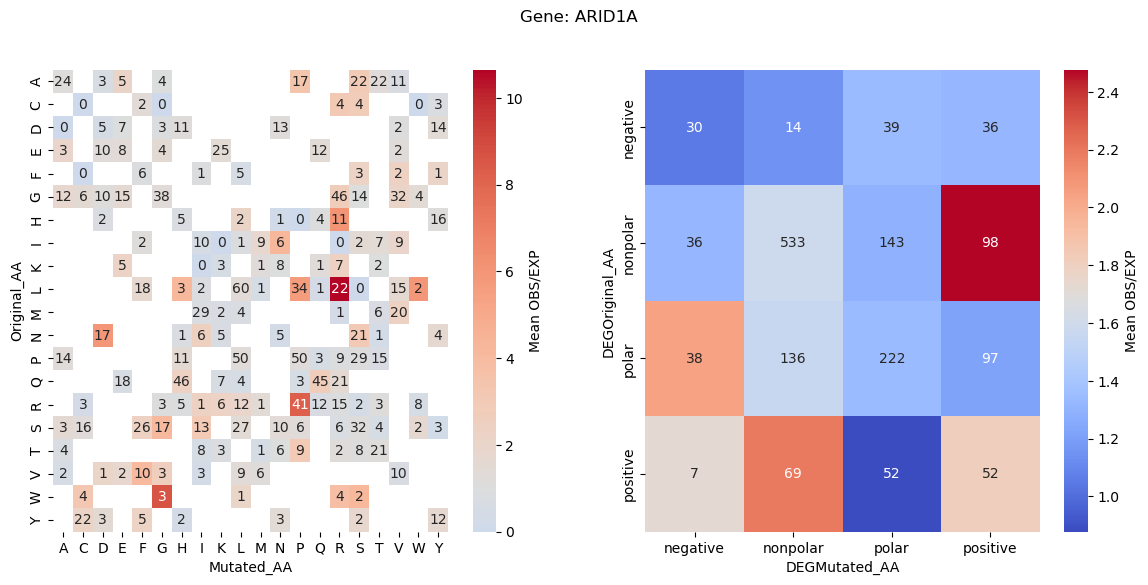

Gene: CDKN1A


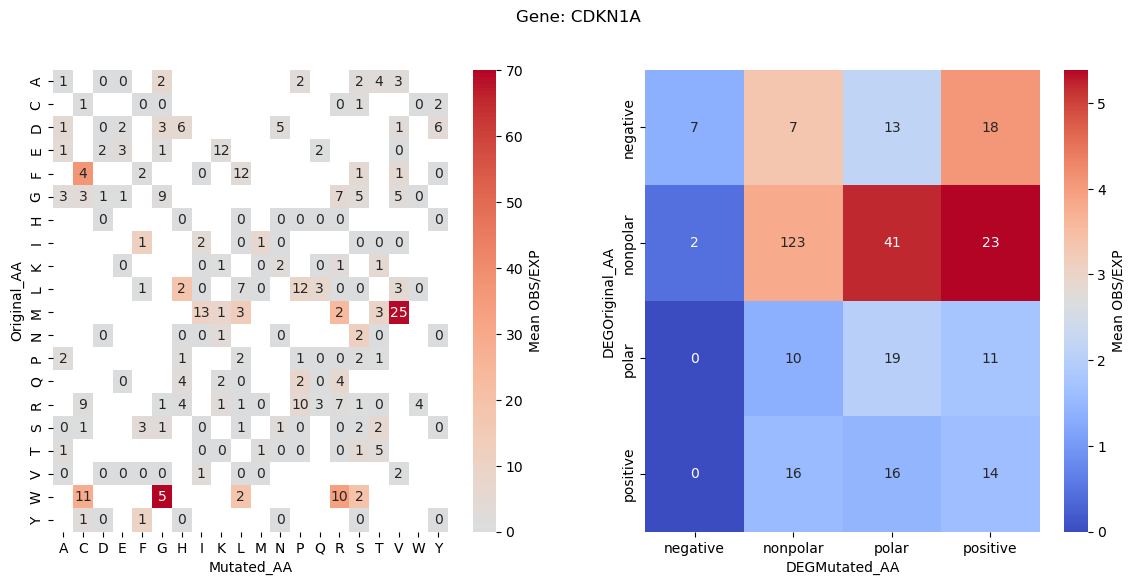

Gene: CREBBP


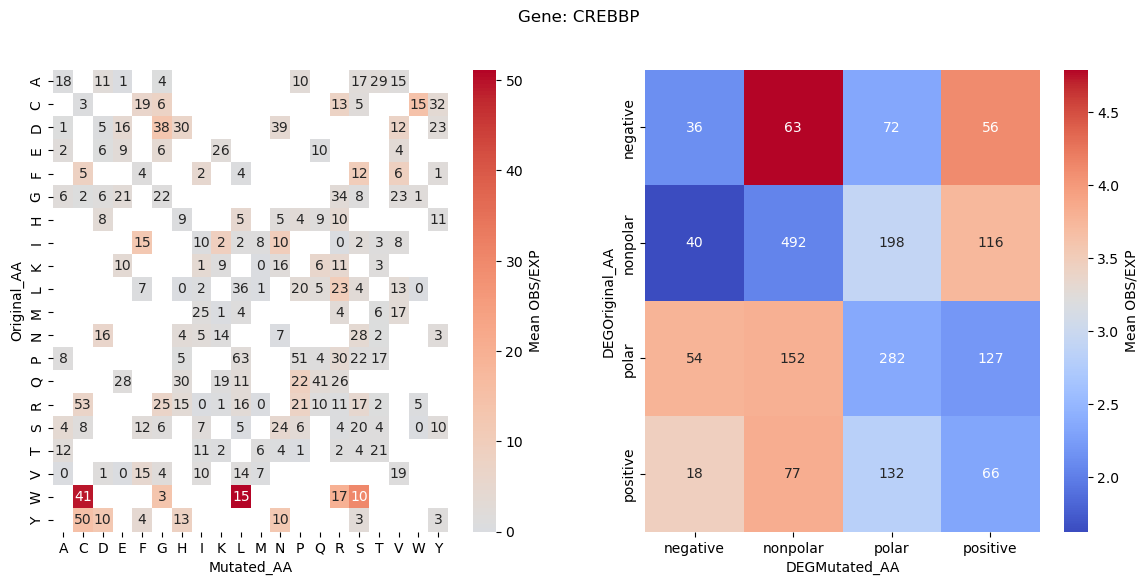

Gene: EP300


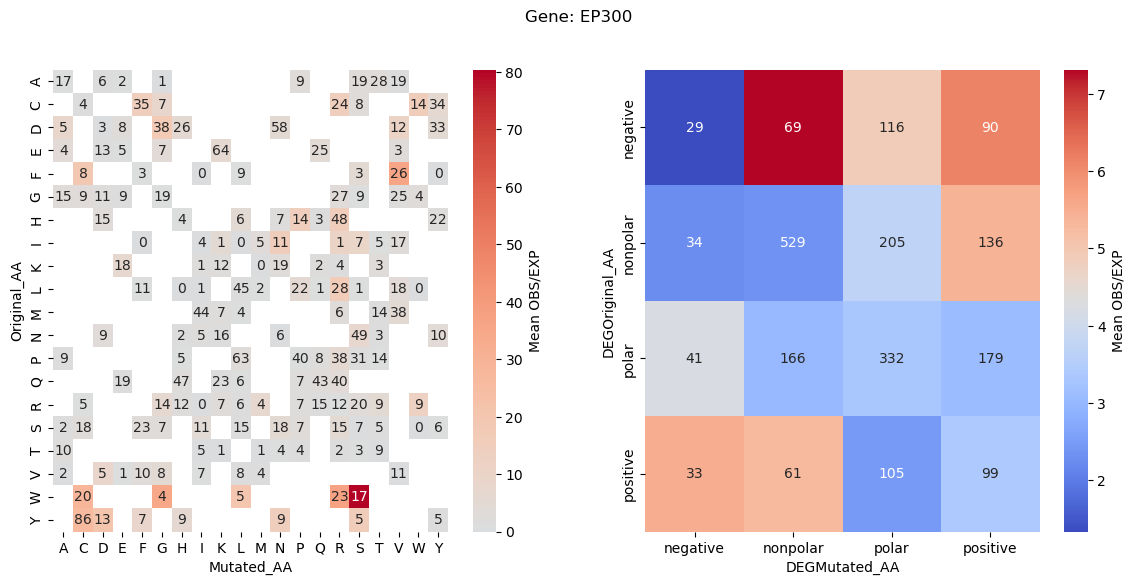

Gene: FGFR3


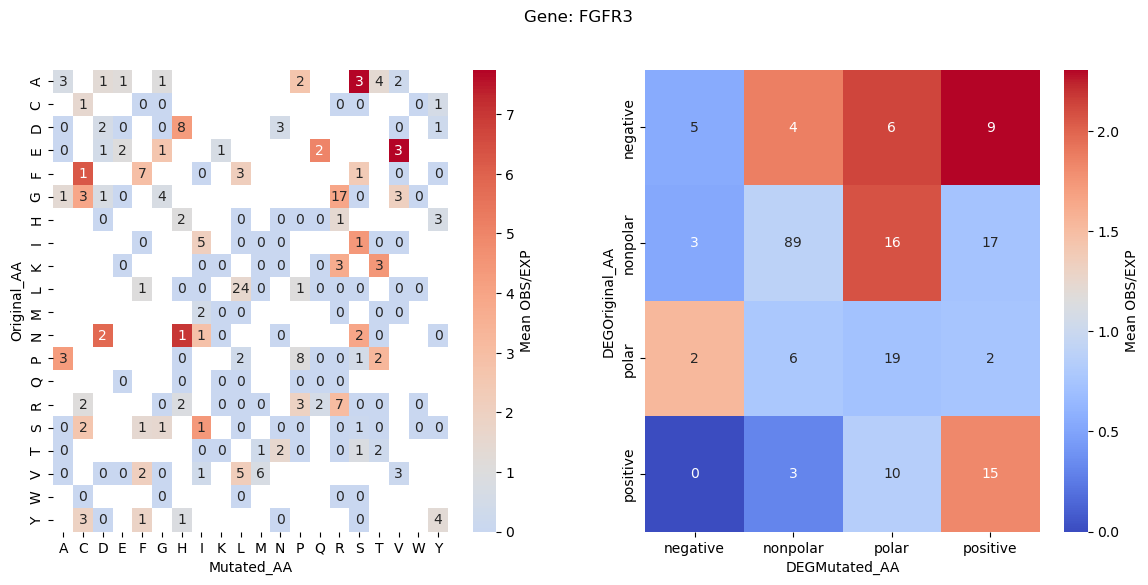

Gene: FOXQ1


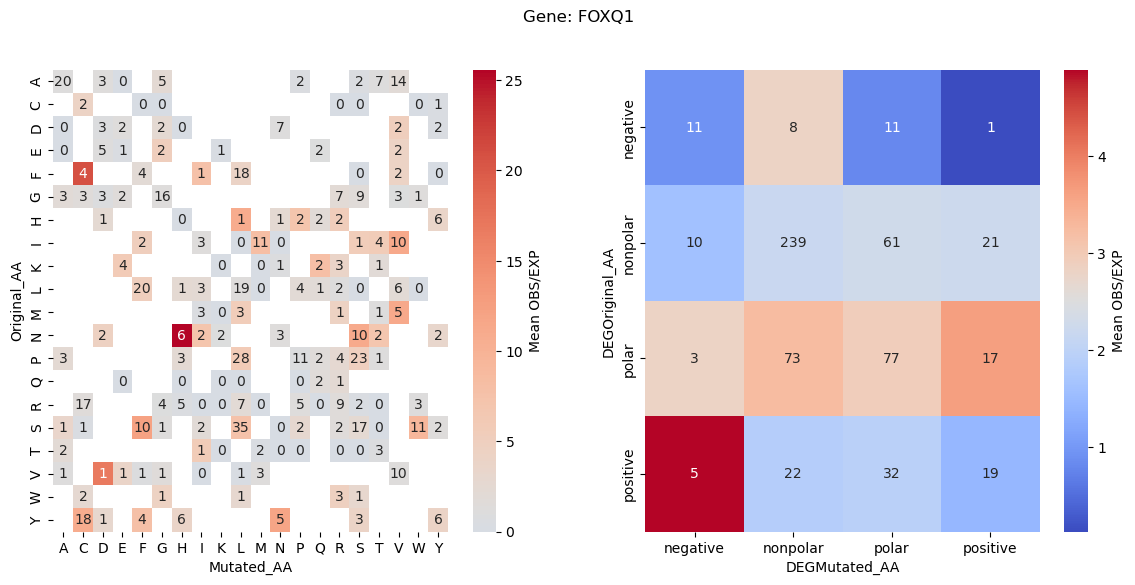

Gene: KDM6A


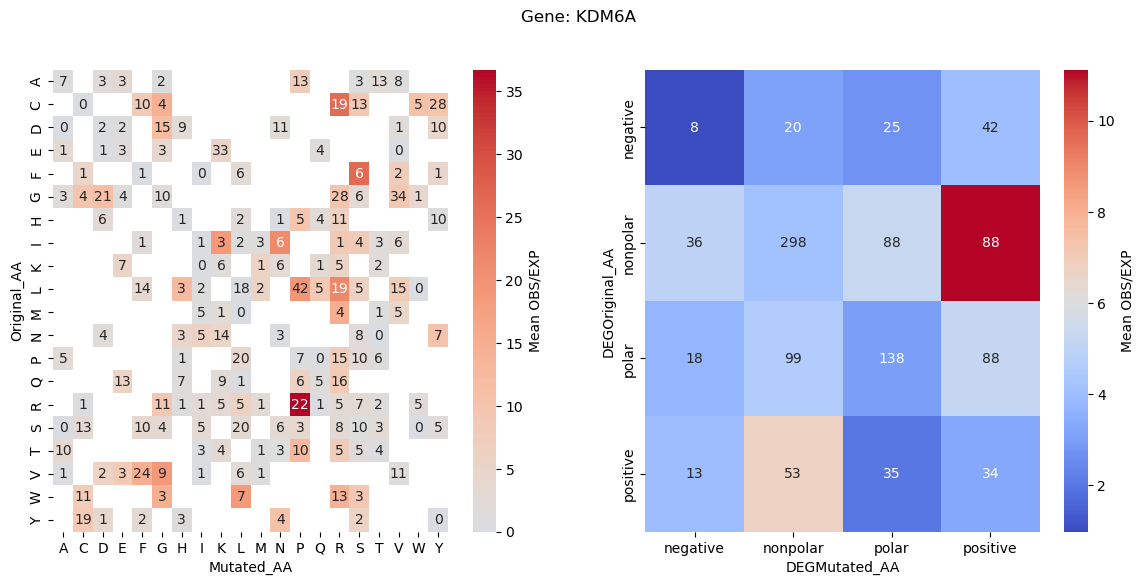

Gene: KMT2C


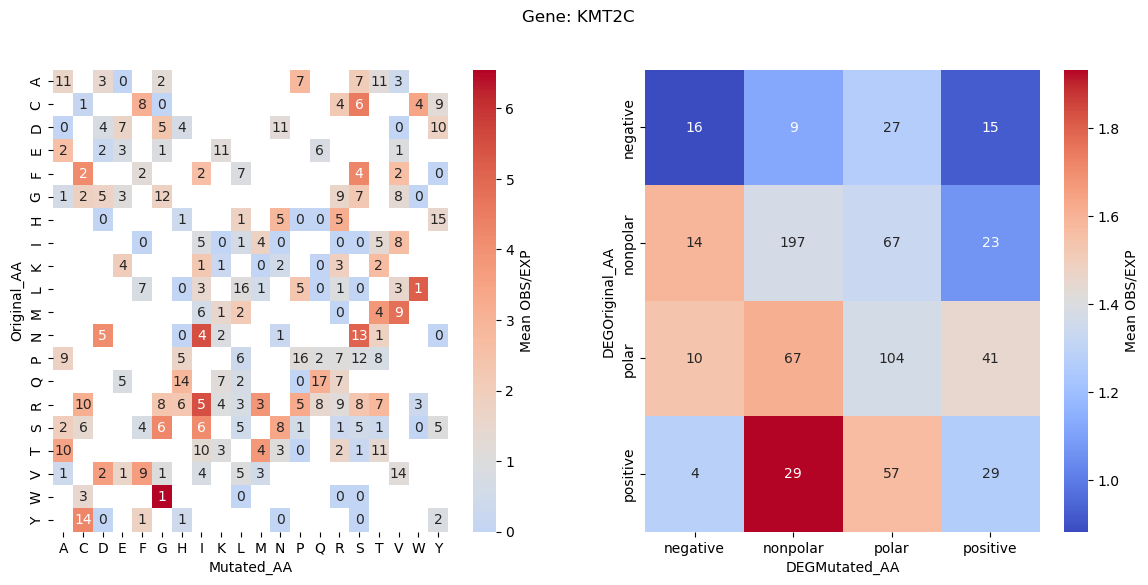

Gene: KMT2D


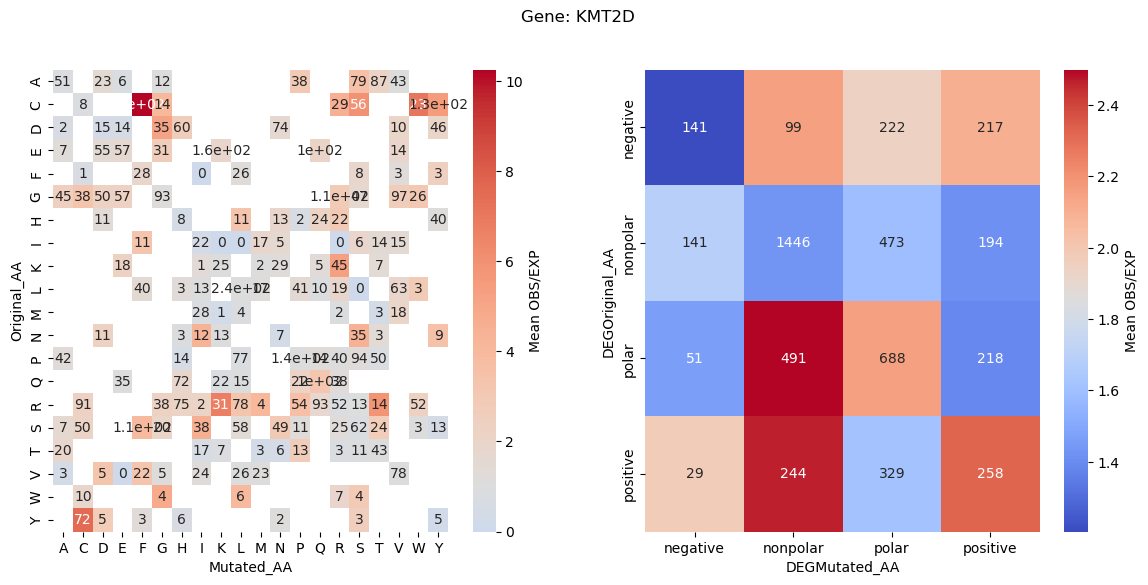

Gene: NOTCH2


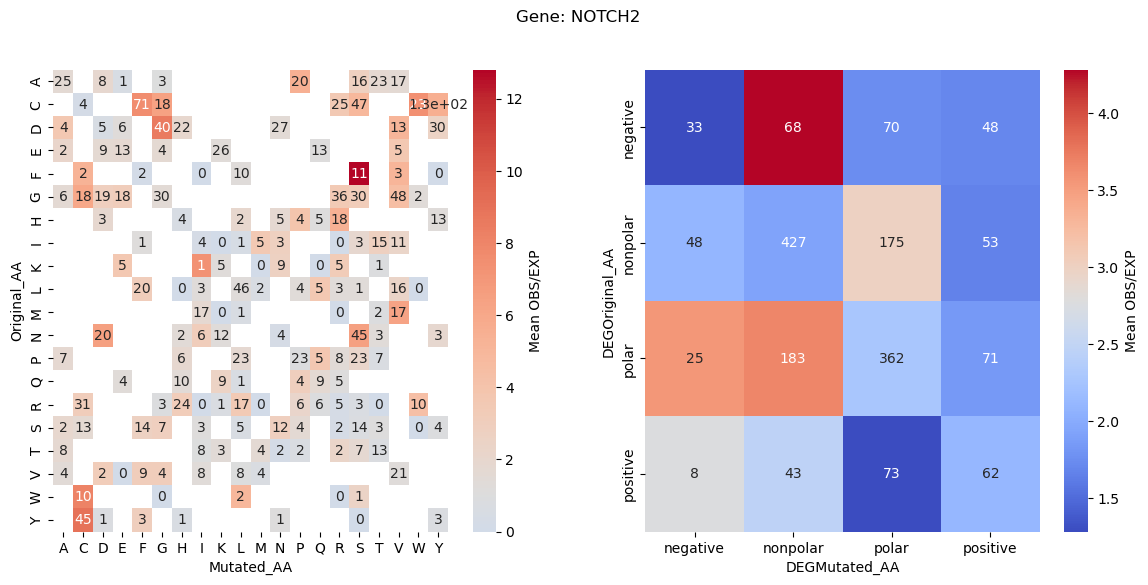

Gene: PIK3CA


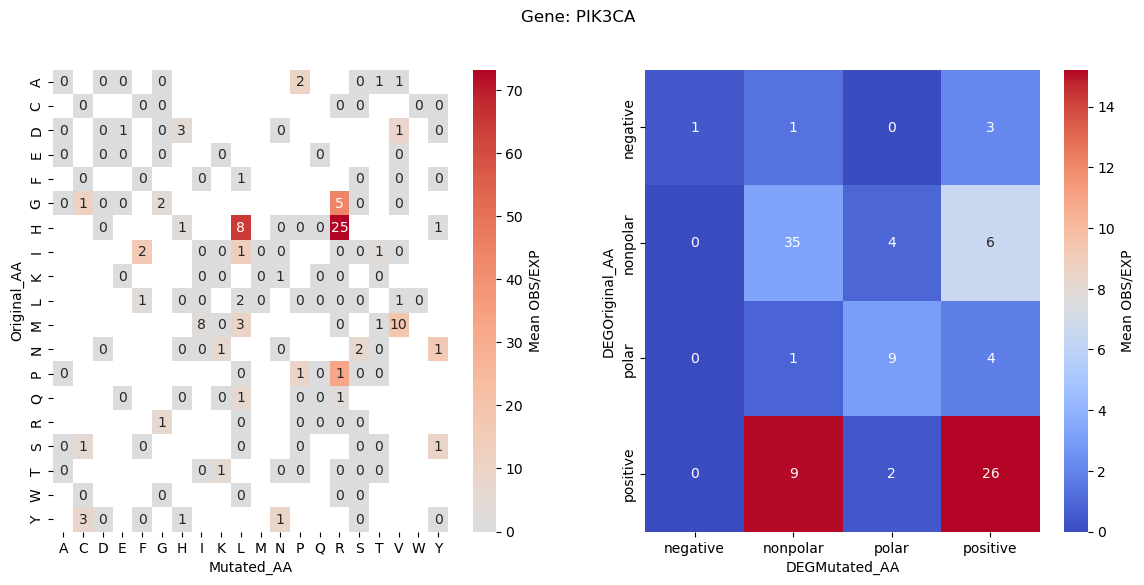

Gene: RB1


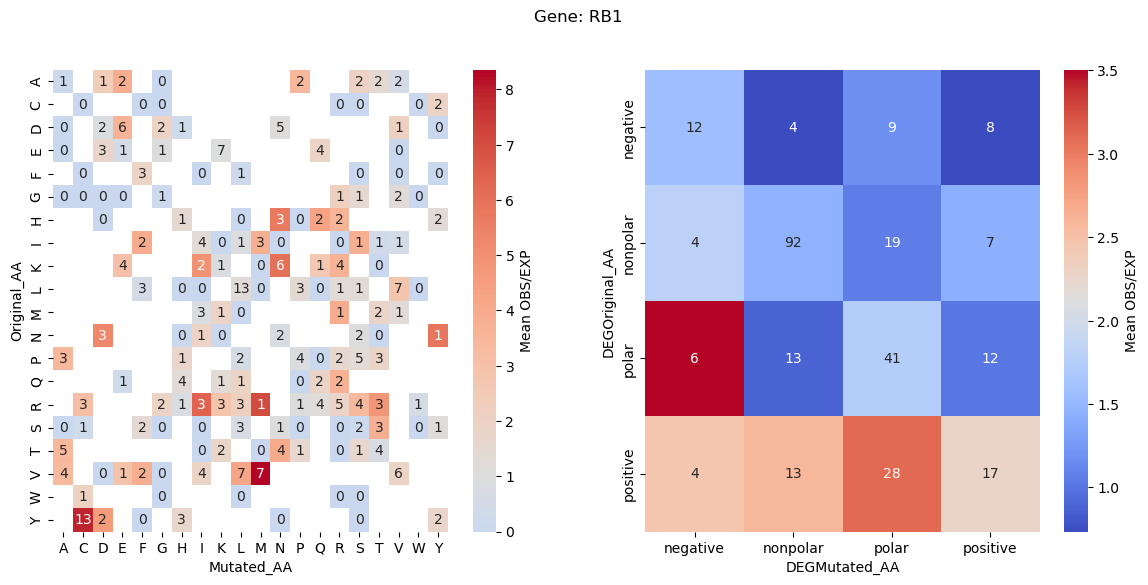

Gene: RBM10


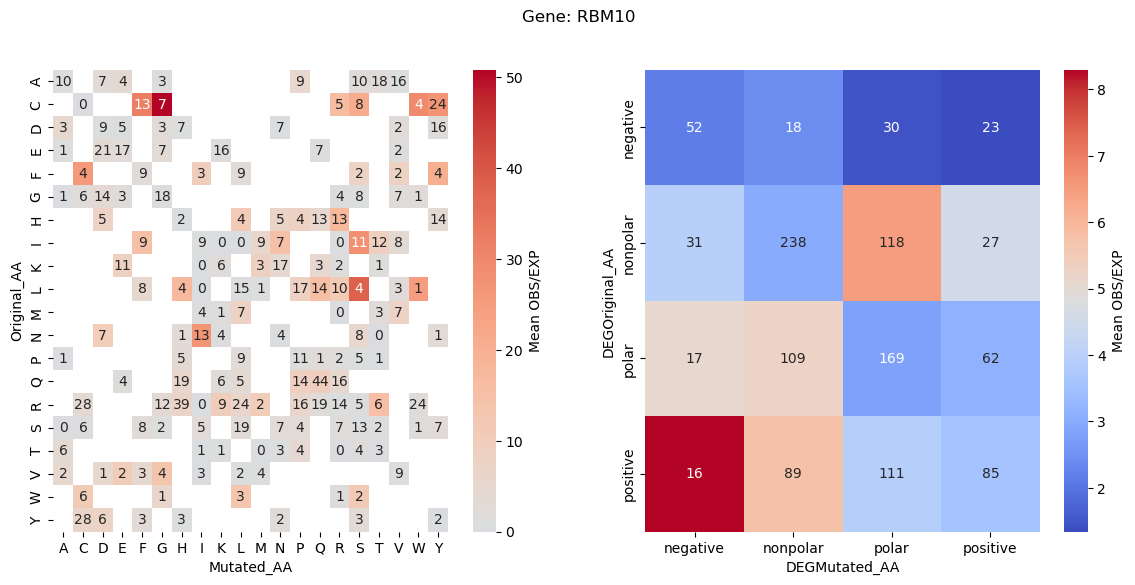

Gene: STAG2


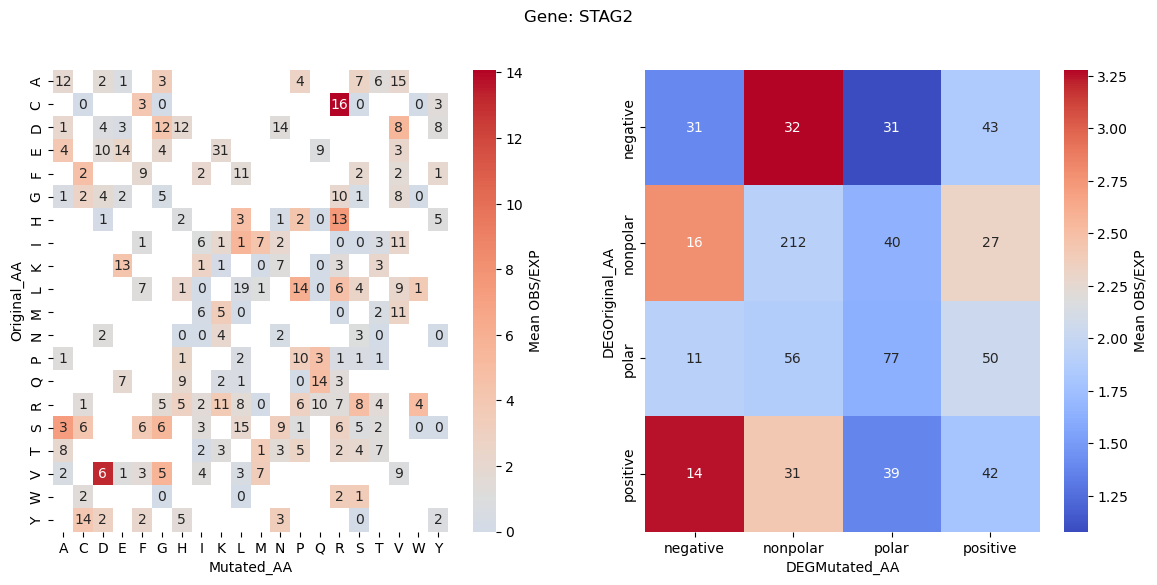

Gene: TERTpromoter


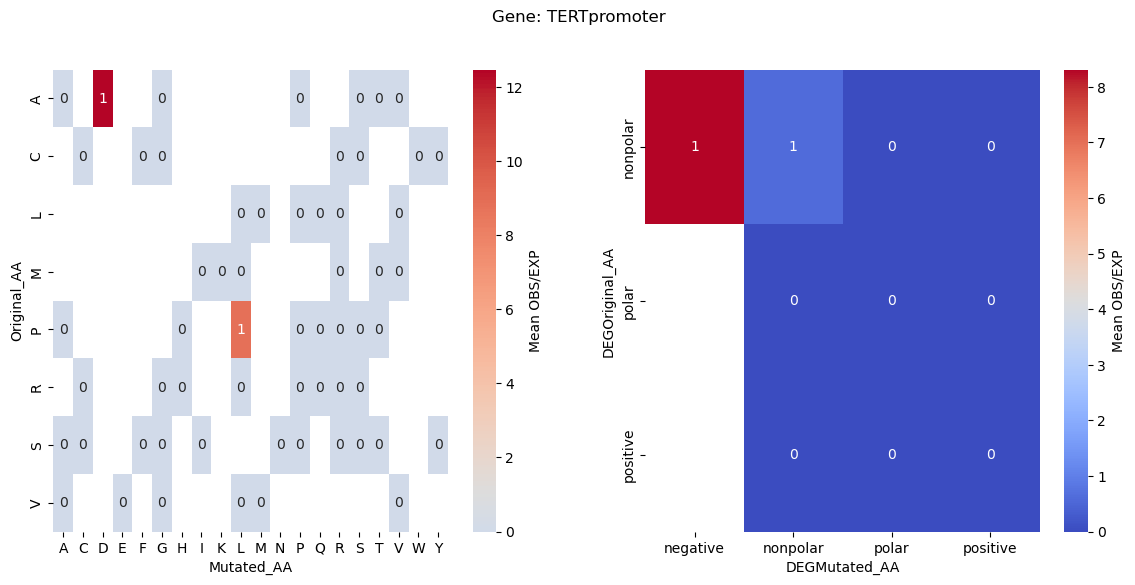

Gene: TP53


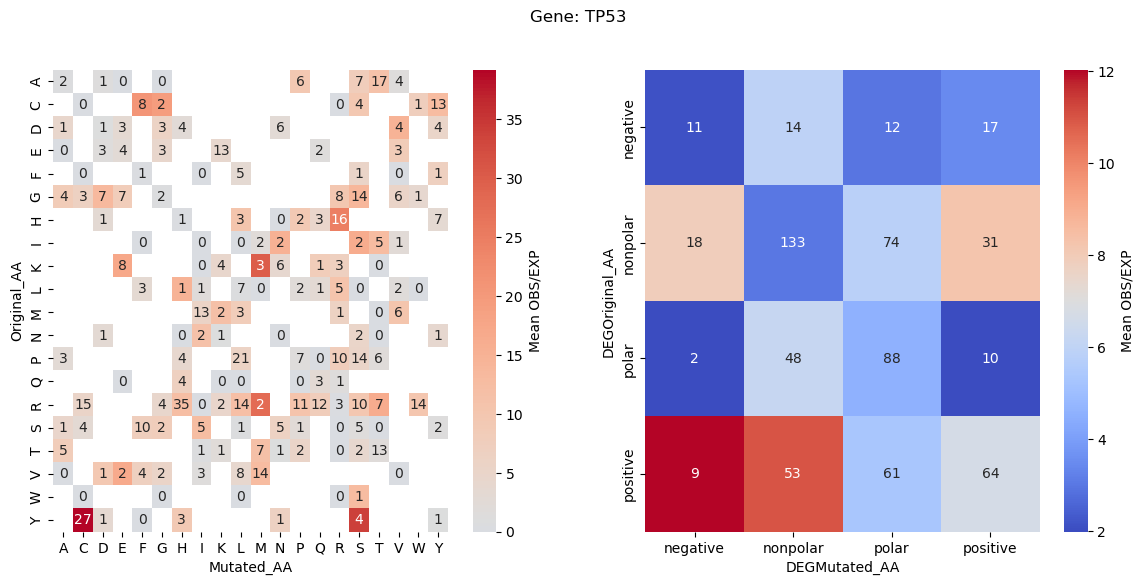

In [7]:
for gene in mutated_data["GENE"].unique():
    gene_data = mutated_data[mutated_data["GENE"] == gene]
    print(f"Gene: {gene}")

    ## Per amino-acid
    mean_impact = gene_data.groupby(by = ["Amino_acids", "Original_AA", "Mutated_AA",
                                            "DEG_Amino_acid", "DEGOriginal_AA", "DEGMutated_AA"]).agg(
                                                {"OBS/EXP": "mean", "OBSERVED_MUTS": "sum", "EXPECTED_MUTS": "sum"}
                                                ).reset_index()
    mean_impact["computed_OBS/EXP"] = mean_impact["OBSERVED_MUTS"] / mean_impact["EXPECTED_MUTS"]

    pivotted_table = mean_impact.pivot(index="Original_AA", columns="Mutated_AA", values="OBS/EXP")
    pivotted_table = pivotted_table.reindex(index=aminoacid_index, columns=aminoacid_index)

    pivotted_table_annot = mean_impact.pivot(index="Original_AA", columns="Mutated_AA", values="OBSERVED_MUTS")
    pivotted_table_annot = pivotted_table_annot.reindex(index=aminoacid_index, columns=aminoacid_index)
    pivotted_table_annot = pivotted_table_annot.round(0).fillna(0).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                            #  gridspec_kw={'width_ratios': [1, 0.5]}
                             )
    sns.heatmap(pivotted_table, cmap = 'coolwarm', center=1, cbar_kws={'label': 'Mean OBS/EXP'},
                    annot=pivotted_table_annot,
                    ax=axes[0])

    ## Grouped amino acids
    deg_mean_impact = gene_data.groupby(by = ["DEG_Amino_acid", "DEGOriginal_AA", "DEGMutated_AA"]).agg(
                                                {"OBS/EXP": "mean", "OBSERVED_MUTS": "sum", "EXPECTED_MUTS": "sum"}
                                                ).reset_index()
    deg_mean_impact["computed_OBS/EXP"] = deg_mean_impact["OBSERVED_MUTS"] / deg_mean_impact["EXPECTED_MUTS"]
    deg_pivotted_table = deg_mean_impact.pivot(index="DEGOriginal_AA", columns="DEGMutated_AA", values="OBS/EXP")
    deg_pivotted_table = deg_pivotted_table.reindex(index=groups_order, columns=groups_order)
    deg_pivotted_table_annot = deg_mean_impact.pivot(index="DEGOriginal_AA", columns="DEGMutated_AA", values="OBSERVED_MUTS")
    deg_pivotted_table_annot = deg_pivotted_table_annot.reindex(index=groups_order, columns=groups_order)
    deg_pivotted_table_annot = deg_pivotted_table_annot.round(0).fillna(0).astype(int)

    sns.heatmap(deg_pivotted_table, cmap = 'coolwarm', cbar_kws={'label': 'Mean OBS/EXP'},
                annot=deg_pivotted_table_annot,
                fmt="d",
                ax=axes[1])

    plt.suptitle(f"Gene: {gene}")
    plt.show()